<a href="https://colab.research.google.com/github/Tienndat2306/TH_DeepLearning_Tuan4/blob/main/CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("Label train:", y_train.shape)
print("Label test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)
Label train: (50000, 1)
Label test : (10000, 1)


In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


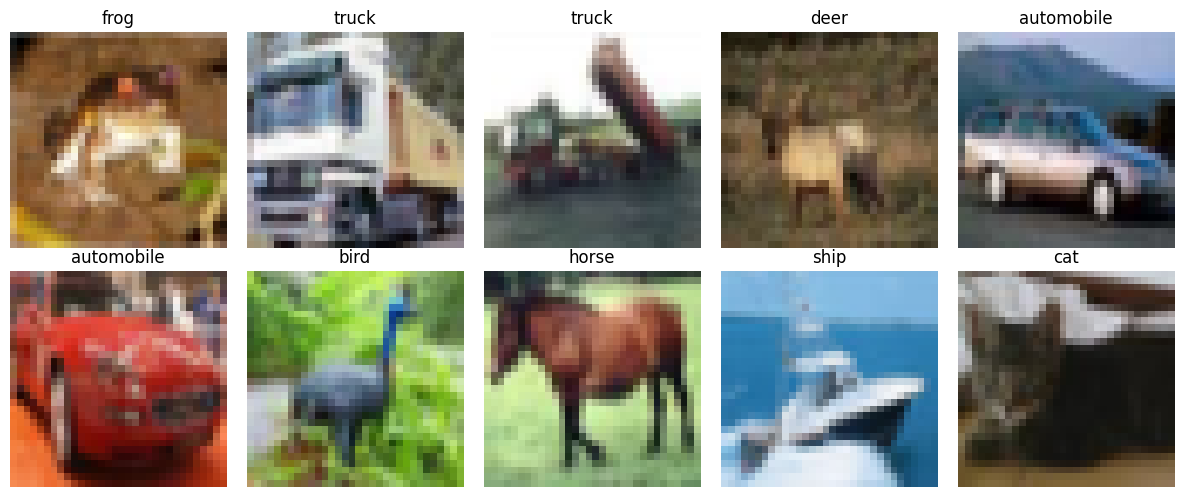

In [5]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(12,5)
)

axes = axes.ravel()

for i in range(10):

    axes[i].imshow(X_train[i])

    axes[i].set_title(
        class_names[y_train[i][0]]
    )

    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


In [8]:
model = Sequential()

# Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

# Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

# Block 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    batch_size=128,
    epochs=20,
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.4422 - loss: 1.5794 - val_accuracy: 0.2906 - val_loss: 2.6267
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5880 - loss: 1.1656 - val_accuracy: 0.6696 - val_loss: 0.9355
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6523 - loss: 0.9901 - val_accuracy: 0.6934 - val_loss: 0.8774
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6918 - loss: 0.8743 - val_accuracy: 0.6714 - val_loss: 0.9111
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7270 - loss: 0.7802 - val_accuracy: 0.7086 - val_loss: 0.8257
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7532 - loss: 0.7003 - val_accuracy: 0.7260 - val_loss: 0.7903
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7786 - loss: 0.6291 - val_accuracy: 0.7332 - val_loss: 0.7651
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8005 - loss: 0.5632 - val_accuracy

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\n===== KẾT QUẢ =====")

print("Loss:", test_loss)

print(
    f"Accuracy: {test_accuracy*100:.2f}%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7557 - loss: 1.0812

===== KẾT QUẢ =====
Loss: 1.0812445878982544
Accuracy: 75.57%


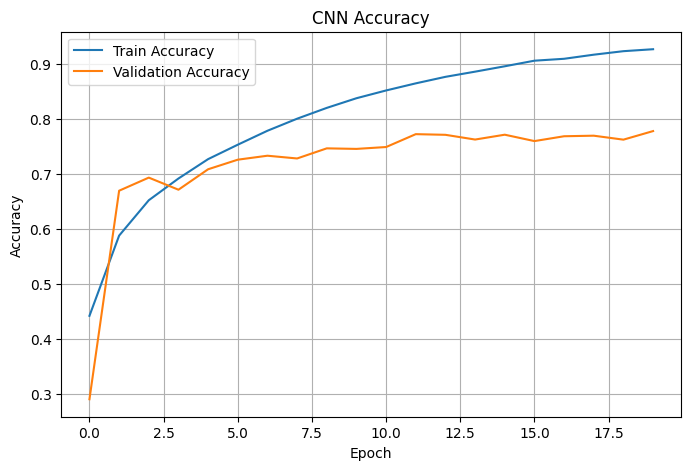

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Accuracy")

plt.legend()

plt.grid()

plt.show()

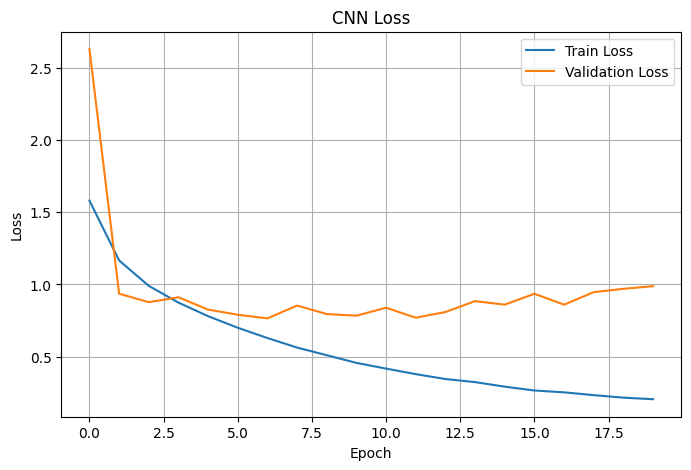

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Loss")

plt.legend()

plt.grid()

plt.show()

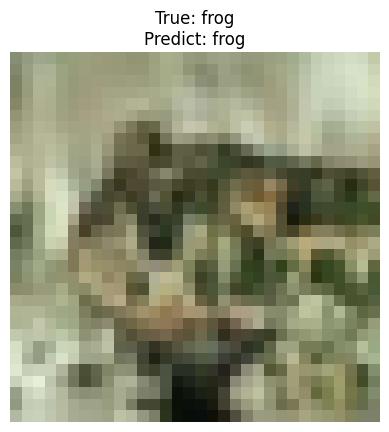

In [18]:
index = np.random.randint(
    0,
    len(X_test)
)

image = X_test[index]

prediction = model.predict(
    image.reshape(1,32,32,3),
    verbose=0
)

predicted_class = np.argmax(prediction)

true_class = np.argmax(y_test[index])

plt.imshow(image)

plt.title(
    f"True: {class_names[true_class]}\n"
    f"Predict: {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()

Saving horse.jpg to horse.jpg


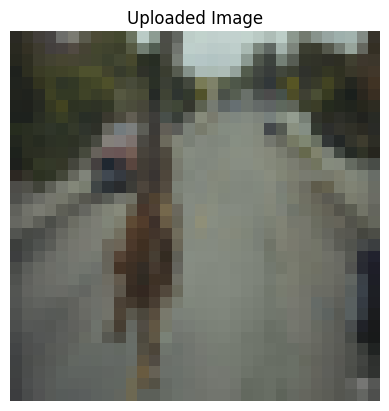


===== KẾT QUẢ DỰ ĐOÁN =====
Class: horse
Confidence: 84.14%

Xác suất từng lớp:
airplane: 0.01%
automobile: 0.00%
bird: 0.30%
cat: 9.03%
deer: 0.49%
dog: 5.99%
frog: 0.02%
horse: 84.14%
ship: 0.00%
truck: 0.00%


In [22]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

for file_name in uploaded.keys():

    img = Image.open(file_name)

    img = img.resize((32,32))

    img = np.array(img)

    if len(img.shape) == 2:

        img = np.stack(
            (img,)*3,
            axis=-1
        )

    img = img.astype("float32") / 255.0

    plt.imshow(img)

    plt.title("Uploaded Image")

    plt.axis("off")

    plt.show()

    prediction = model.predict(
        img.reshape(1,32,32,3),
        verbose=0
    )

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    print(
        "\n===== KẾT QUẢ DỰ ĐOÁN ====="
    )

    print(
        "Class:",
        class_names[predicted_class]
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print("\nXác suất từng lớp:")

    for i, prob in enumerate(prediction[0]):

        print(
            f"{class_names[i]}: "
            f"{prob*100:.2f}%"
        )